In [47]:
##################################################################### 
#1. Data Preprocessing
######################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. 데이터셋 활용 및 삭제 (Drop)

df = pd.read_csv('Clean_Dataset.csv')

# 2. 과적합을 유발하는 편명(flight)과 불필요한 인덱스 삭제
columns_to_drop = []
if 'Unnamed: 0' in df.columns:
    columns_to_drop.append('Unnamed: 0')
if 'flight' in df.columns:
    columns_to_drop.append('flight')
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# 3. 변수 생성 (Feature Engineering)
# 3-1. 노선(Route) 변수 생성: 출발지_도착지, 중복 제거 
df['route'] = df['source_city'] + "_" + df['destination_city']
df.drop(columns=['source_city', 'destination_city'], inplace=True)
# 3-2. 예약 시점 구간 변수 생성
# [피드백 2번 반영] -1부터 시작하여 0일 데이터 손실(결측치) 완벽 방지
bins = [-1, 7, 21, df['days_left'].max()]
labels = ['1~7일 전(출발 직전)', '8~21일 전(단기)', '22일 이상(장기)']
df['booking_period'] = pd.cut(df['days_left'], bins=bins, labels=labels)

# 3-3. 타겟 변수 로그 변환 (가격 변동성 학습 최적화)
df['price'] = np.log1p(df['price'])

# =====================================================================
# 2. 숫자로 변환 (Encoding)
# =====================================================================
# ① class (절대 지우지 않고 0과 1로 매핑)
df['class'] = df['class'].map({'Economy': 0, 'Business': 1})

# ② stops: 직항 0, 1회 경유 1, 2회 이상 2
df['stops'] = df['stops'].map({'zero': 0, 'one': 1, 'two_or_more': 2})

# ③ 문자열 데이터 원-핫 인코딩
df_encoded = pd.get_dummies(df, drop_first=True)

# =====================================================================
# 4. 데이터 분리 (Train/Test Split - 8:2 비율)
# =====================================================================
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== 최종 전처리 및 데이터 분리 완료 ===")
print(f"X_train 데이터 크기: {X_train.shape}")
print(f"X_test 데이터 크기: {X_test.shape}")
print(f"y_train 데이터 크기: {y_train.shape}")
print(f"y_test 데이터 크기: {y_test.shape}")

# 1. 전체 전처리 완료된 데이터 하나로 저장하기
df.to_csv('final_preprocessed_data.csv', index=False, encoding='utf-8-sig')

# 2. (선택사항) 머신러닝용으로 분리된 Train / Test 데이터를 각각 저장하기
# 정답(y) 컬럼을 다시 붙여서 보기 좋게 하나의 파일로 만듭니다.
train_df = pd.concat([X_train, y_train], axis=1)
train_df.to_csv('train_data.csv', index=False, encoding='utf-8-sig')

test_df = pd.concat([X_test, y_test], axis=1)
test_df.to_csv('test_data.csv', index=False, encoding='utf-8-sig')

print("CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.")

=== 최종 전처리 및 데이터 분리 완료 ===
X_train 데이터 크기: (240122, 50)
X_test 데이터 크기: (60031, 50)
y_train 데이터 크기: (240122,)
y_test 데이터 크기: (60031,)
CSV 파일 저장이 완료되었습니다. 폴더를 확인해 주세요.


In [48]:
##################################################################### 
#2. final_preprocessed_data.csv 의  각 모델별 성능평가 
######################################################################

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.linear_model import Ridge, Lasso, RidgeCV  # Ridge, Lasso 추가
from sklearn.ensemble import RandomForestRegressor      # RandomForest 추가
from xgboost import XGBRegressor                        # XGBoost 추가
from lightgbm import LGBMRegressor                      # LightGBM 추가
import numpy as np                                      # np.sqrt를 위한 넘파이

models = {
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForest': RandomForestRegressor(),
    'XGBoost': XGBRegressor(),
    'LightGBM': LGBMRegressor()
}

results = {}
for name,model in models.items():
    model.fit(X_train,y_train)
    predict = model.predict(X_test)
    
    #calculating root mean squared error
    r2 = r2_score(y_test,predict)
    mae = mean_absolute_error(y_test,predict)
    rmse = np.sqrt(mean_squared_error(y_test,predict))
    results[name] = {
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse
    }
    print(f"\n{name} Performance:")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAE  = {mae:.2f}")
    print(f"  R²   = {r2:.4f}")


Ridge Performance:
  RMSE = 0.32
  MAE  = 0.25
  R²   = 0.9182

Lasso Performance:
  RMSE = 1.06
  MAE  = 0.93
  R²   = 0.0846

RandomForest Performance:
  RMSE = 0.14
  MAE  = 0.07
  R²   = 0.9852

XGBoost Performance:
  RMSE = 0.18
  MAE  = 0.13
  R²   = 0.9732

LightGBM Performance:
  RMSE = 0.20
  MAE  = 0.15
  R²   = 0.9661


In [49]:
##################################################################### 
# 3. Ridge 모델 비교 분석
######################################################################

# =====================================================================
# 1. 클래스별 데이터 분리 및 학습 함수
# =====================================================================
def analyze_ridge_log_scale(target_df, class_name):
    # 1-1. 데이터 분리 (price는 이미 로그 변환된 상태)
    X = target_df.drop(columns=['price'])
    y = target_df['price']
    
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # 1-2. 피처 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_c)
    X_test_scaled = scaler.transform(X_test_c)
    
    # 1-3. 릿지 모델 학습 (최적 alpha 자동 탐색)
    # 결정계수(R2)를 기준으로 최적의 모델을 선택합니다.
    model = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], scoring='r2')
    model.fit(X_train_scaled, y_train_c)
    
    # 1-4. 예측 수행 (로그 스케일 그대로)
    y_pred_log = model.predict(X_test_scaled)
    
    # 1-5. 성능 지표 계산 (로그 값 기준)
    r2 = r2_score(y_test_c, y_pred_log)
    mae = mean_absolute_error(y_test_c, y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_test_c, y_pred_log))
    
    print(f"\n--- [{class_name}] Ridge 분석 결과 (Log Scale) ---")
    print(f"최적 Alpha 값: {model.alpha_}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    
    # 회귀 계수(영향력) 데이터프레임 생성
    coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
    return coef_df, r2

# =====================================================================
# 2. 실행: 이코노미(0)와 비즈니스(1) 분리 분석
# =====================================================================
# 이코노미 데이터 분석
eco_coef, eco_r2 = analyze_ridge_log_scale(df_encoded[df_encoded['class'] == 0], "Economy")

# 비즈니스 데이터 분석
bus_coef, bus_r2 = analyze_ridge_log_scale(df_encoded[df_encoded['class'] == 1], "Business")

# =====================================================================
# 3. 영향력(Coefficient) 상위 10개 변수 비교
# =====================================================================
print("\n[Economy: 가격 상승 기여도 Top 10]")
print(eco_coef.sort_values(by='Coefficient', ascending=False).head(10))

print("\n[Business: 가격 상승 기여도 Top 10]")
print(bus_coef.sort_values(by='Coefficient', ascending=False).head(10))


--- [Economy] Ridge 분석 결과 (Log Scale) ---
최적 Alpha 값: 10.0
R2 Score: 0.6126
MAE: 0.2557
RMSE: 0.3270

--- [Business] Ridge 분석 결과 (Log Scale) ---
최적 Alpha 값: 10.0
R2 Score: 0.6118
MAE: 0.1333
RMSE: 0.1752

[Economy: 가격 상승 기여도 Top 10]
                    Feature  Coefficient
8           airline_Vistara     0.294645
4         airline_Air_India     0.225354
0                     stops     0.138948
5          airline_GO_FIRST     0.137745
6            airline_Indigo     0.128634
7          airline_SpiceJet     0.088527
2                  duration     0.043903
40      route_Kolkata_Delhi     0.042633
38  route_Kolkata_Bangalore     0.039505
42     route_Kolkata_Mumbai     0.038212

[Business: 가격 상승 기여도 Top 10]
                    Feature  Coefficient
0                     stops     0.182372
8           airline_Vistara     0.036053
22   route_Bangalore_Mumbai     0.030722
43   route_Mumbai_Bangalore     0.029767
18       arrival_time_Night     0.027806
47     route_Mumbai_Kolkata     0.02647

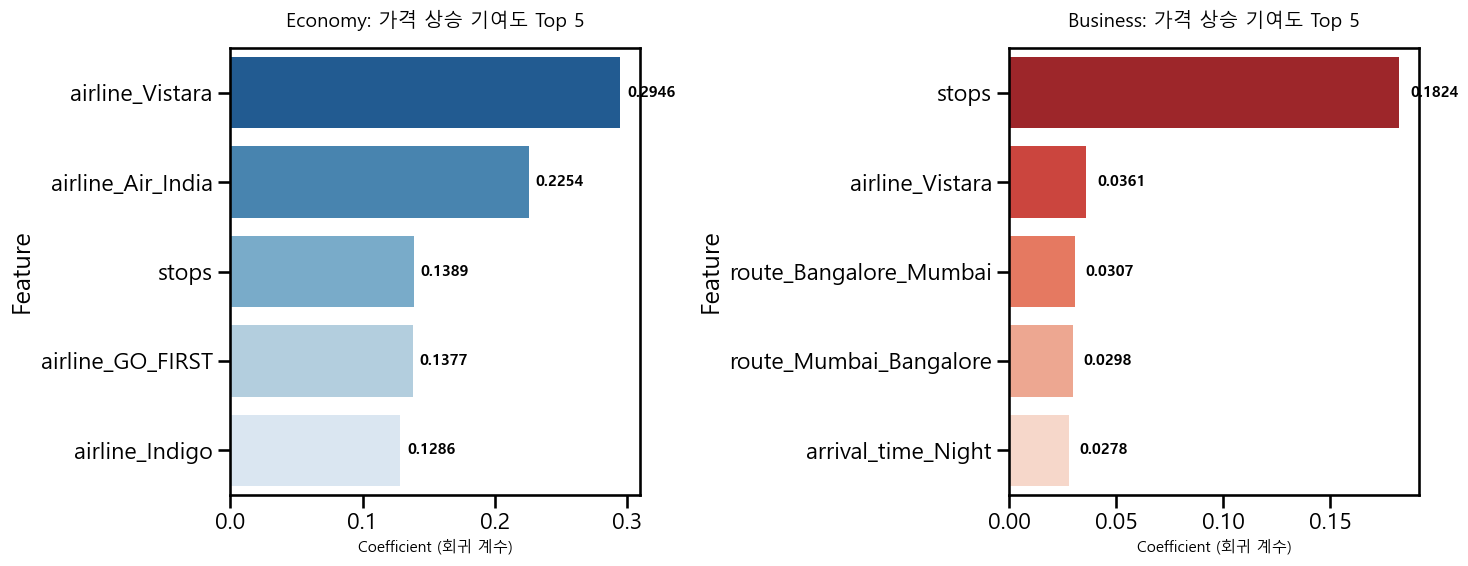

In [50]:
##################################################################### 
#4. 릿지 기반 가격 상승 기여도 시각화
######################################################################
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 상위 5개 데이터 추출 
eco_top5 = eco_coef.sort_values(by='Coefficient', ascending=False).head(5)
bus_top5 = bus_coef.sort_values(by='Coefficient', ascending=False).head(5)

# 3. 그래프 그리기 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Economy 시각화 (Top 5) ---
sns.barplot(x='Coefficient', y='Feature', data=eco_top5, ax=axes[0], 
            palette='Blues_r', hue='Feature', legend=False)
axes[0].set_title('Economy: 가격 상승 기여도 Top 5', fontsize=14, pad=15)
axes[0].set_xlabel('Coefficient (회귀 계수)', fontsize=11)

# 숫자 표시 (Economy)
for i, v in enumerate(eco_top5['Coefficient']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

# --- Business 시각화 (Top 5) ---
sns.barplot(x='Coefficient', y='Feature', data=bus_top5, ax=axes[1], 
            palette='Reds_r', hue='Feature', legend=False)
axes[1].set_title('Business: 가격 상승 기여도 Top 5', fontsize=14, pad=15)
axes[1].set_xlabel('Coefficient (회귀 계수)', fontsize=11)

# 숫자 표시 (Business)
for i, v in enumerate(bus_top5['Coefficient']):
    axes[1].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [53]:
##################################################################### 
#5. LightGBM 모델 비교 분석
######################################################################

from sklearn.model_selection import GridSearchCV

# 1. LightGBM용 파라미터 그리드 설정
lgbm_param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'random_state': [42],
    'force_col_wise': [True], # 대량 데이터 처리 시 메모리 효율을 위해 추가
    'verbose': [-1]
}

# 2. 모델 최적화 함수 정의
def tune_lgbm_model(target_df, label):
    # 데이터 분리
    X = target_df.drop(columns=['price'])
    y = target_df['price'] # 이미 로그 변환된 상태
    
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 기본 모델 생성
    lgbm_model = LGBMRegressor()

    # GridSearchCV 설정 (cv=3으로 속도 확보)
    grid_search = GridSearchCV(
        estimator=lgbm_model, 
        param_grid=lgbm_param_grid, 
        cv=3, 
        scoring='r2', 
        verbose=1
    )

    print(f"\n--- [{label}] LightGBM 최적화 시작 ---")
    grid_search.fit(X_train_l, y_train_l)

    # 최적 결과 저장
    best_params = grid_search.best_params_
    best_model = grid_search.best_estimator_
    
    # 예측 및 평가 (로그 스케일 기준)
    y_pred = best_model.predict(X_test_l)
    r2 = r2_score(y_test_l, y_pred)
    mae = mean_absolute_error(y_test_l, y_pred)
    mse = mean_squared_error(y_test_l, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"최적 파라미터: {best_params}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE (Log): {mae:.4f}")
    print(f"RMSE (Log): {rmse:.4f}")

    # 중요도 추출
    imp_df = pd.DataFrame({
        'Feature': X.columns, 
        'Importance': best_model.feature_importances_
    })
    return best_model, imp_df


# 3. 실행: 이코노미와 비즈니스 각각 최적화
best_lgbm_eco, lgbm_eco_imp = tune_lgbm_model(df_encoded[df_encoded['class'] == 0], "Economy")
best_lgbm_bus, lgbm_bus_imp = tune_lgbm_model(df_encoded[df_encoded['class'] == 1], "Business")


--- [Economy] LightGBM 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'force_col_wise': True, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'random_state': 42, 'subsample': 0.8, 'verbose': -1}
R2 Score: 0.8814
MAE (Log): 0.1243
RMSE (Log): 0.1809

--- [Business] LightGBM 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'force_col_wise': True, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'random_state': 42, 'subsample': 0.8, 'verbose': -1}
R2 Score: 0.9212
MAE (Log): 0.0504
RMSE (Log): 0.0789


In [56]:
##################################################################### 
#5. XGBoost 모델 비교 분석
######################################################################

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# 1. XGBoost용 파라미터 그리드 설정
xgb_param_grid = {
    'n_estimators': [500, 1000],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'random_state': [42]
}

# 2. 모델 최적화 및 분석 함수 정의
def analyze_xgb_model(target_df, label):
    X = target_df.drop(columns=['price'])
    y = target_df['price'] # 로그 변환된 가격
    
    X_train_x, X_test_x, y_train_x, y_test_x = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 모델 생성 (verbosity=0으로 내부 경고 차단)
    xgb_model = XGBRegressor(verbosity=0)

    # GridSearchCV 설정 (verbose=1로 진행 상황만 한 줄씩 확인)
    grid_search = GridSearchCV(
        estimator=xgb_model, 
        param_grid=xgb_param_grid, 
        cv=3, 
        scoring='r2', 
        verbose=1 
    )

    print(f"\n--- [{label}] XGBoost 최적화 시작 ---")
    grid_search.fit(X_train_x, y_train_x)

    best_model = grid_search.best_estimator_
    
    # 예측 및 지표 계산 (로그 스케일 기준)
    y_pred = best_model.predict(X_test_x)
    r2 = r2_score(y_test_x, y_pred)
    mae = mean_absolute_error(y_test_x, y_pred)
    mse = mean_squared_error(y_test_x, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"최적 파라미터: {grid_search.best_params_}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE (Log): {mae:.4f}")
    print(f"RMSE (Log): {rmse:.4f}")

    # 1. 중요도 
  
    imp_df = pd.DataFrame({
        'Feature': X.columns, 
        'Importance': best_model.feature_importances_  
    })
    return best_model, imp_df

# 3. 실행: 이코노미와 비즈니스 각각 분석
best_xgb_eco, xgb_eco_gain_top5 = analyze_xgb_model(df_encoded[df_encoded['class'] == 0], "Economy")
best_xgb_bus, xgb_bus_gain_top5 = analyze_xgb_model(df_encoded[df_encoded['class'] == 1], "Business")


--- [Economy] XGBoost 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'random_state': 42, 'subsample': 0.8}
R2 Score: 0.8961
MAE (Log): 0.1149
RMSE (Log): 0.1693

--- [Business] XGBoost 최적화 시작 ---
Fitting 3 folds for each of 8 candidates, totalling 24 fits
최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 1000, 'random_state': 42, 'subsample': 0.8}
R2 Score: 0.9321
MAE (Log): 0.0463
RMSE (Log): 0.0733
